In [24]:
import navis 
import flybrains

import numpy as np
import pandas as pd
import seaserpent as ss
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram

from fafbseg import flywire

flywire.set_default_dataset("wclee_aedes_brain")

Default dataset set to "wclee_aedes_brain".


In [3]:
table = ss.Table("aedes_main", "aedes").to_frame()
table.head()

,supervoxel_id,serial_id,root_id,point_xyz,side,subsubclass,type,group,superclass,axon_tract,...,root_duplicated,soma_xyz,birthtime,nerve,synonyms,flywire_type,instance,receptor,lrcid,serial_id_saved
row_id,,,,,,,,,,,,,,,,,,,,,
d76kgJ7aRSSG8FVDNH4ZWQ,76280889268882312,13765,648518347481404235,"33214,12071,4600",R,<NA>,<NA>,11758.0,central,None,...,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,13765.0
U31NnNtIRySAo2U_QvFpmQ,75226526269985001,10001,648518347509965429,"25416.783203125,20689.4375,4378.982421875",R,G1_G2_G5,G1_G2_G5_PN,10001.0,central,[mALT],...,False,<NA>,<NA>,<NA>,<NA>,VP3+VP1l_ivPN,<NA>,<NA>,C003:193,10001.0
PpXg8uYIQRSh2gGzA5R3cA,75226526269992020,10002,648518347501126977,"25449.474609375,20758.744140625,4378.982421875",R,G1_G2_G5,G1_G2_G5_PN,10002.0,central,[mALT],...,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,C003:195,10002.0
LKO0_NSdQiSLPO25G2RTcw,75648601497466950,10003,648518347488545557,"28597.75,19607.583984375,4773.5",L,RG1,G1_PN,10001.0,central,[mALT],...,False,<NA>,<NA>,<NA>,Marin 2020: VP3+VP1l ivPN,<NA>,<NA>,<NA>,<NA>,10003.0
ElYAergFQuya_RnzVWCo3w,75367126520739993,10004,648518347570434664,"26120.669921875,19894.88671875,4773.5",R,G2,G2_lPN,10004.0,central,[mALT],...,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,C003:244,10004.0


In [4]:
pns = table[table['class'] == 'ALPN']
pns_l = pns[pns.side == 'L']
pns_r = pns[pns.side == 'R']
len(pns_l), len(pns_r)

(303, 299)

In [8]:
# Are there any outdated root IDs?
pns[~flywire.is_latest_root(pns.root_id)]

,supervoxel_id,serial_id,root_id,point_xyz,side,subsubclass,type,group,superclass,axon_tract,...,root_duplicated,soma_xyz,birthtime,nerve,synonyms,flywire_type,instance,receptor,lrcid,serial_id_saved
row_id,,,,,,,,,,,,,,,,,,,,,
UCRJXw-RRD-5GTBQiduFdQ,74451783224957579,10414,648518347555849442,"19597.02734375,15728.3037109375,5081.47607421875",L,<NA>,<NA>,NaN,central,[mALT],...,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,C003:122,10414.0
H3ho8ZBRTfGCqVJ-b7d1uA,74451783224975979,10445,648518347544257946,"19542.345703125,15733.1953125,5089.85791015625",L,G12_G26,G12_G26_PN,10024.0,central,[mALT],...,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,C003:123,10445.0
HKI7poJnTH6erfXWDzE9Aw,74240470968318800,10898,648518347669007458,"18272.326171875,14095.1953125,5373.54150390625",L,<NA>,G48+G59_PN,NaN,central,[mlALT],...,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,C003:096,10898.0
Bayxy7mURW6sLHbAHn209A,74240951669005351,11171,648518347531530193,"17973.830078125,17873.1796875,4688.24072265625",L,G1_G3_G5_G6_G12_G13_G61_G62,G1_G3_G5_G6_G12_G13_G61_G62_PN,10958.0,central,[lALT],...,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,C003:234,11171.0
d5O2E7H4SsunFPTjxrjWtQ,74241020388506875,11419,648518347673779012,"17934,17926,4706",L,G13_G78,G13_G78_PN,10957.0,central,[lALT],...,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,C003:235,11419.0


In [10]:
sk_left = flywire.get_l2_skeleton(pns_l.root_id.unique())
sk_right = flywire.get_l2_skeleton(pns_r.root_id.unique())

Fetching L2 skeletons:   0%|          | 0/291 [00:00<?, ?it/s]

Fetching L2 skeletons:   0%|          | 0/279 [00:00<?, ?it/s]

In [11]:
sk_right_m = navis.mirror_brain(sk_right, template="AEDES")

Mirroring:   0%|          | 0/279 [00:00<?, ?it/s]

In [13]:
dp = navis.make_dotprops(sk_left + sk_right_m, k=5, resample=1000, parallel=True)

Dotprops:   0%|          | 0/570 [00:00<?, ?it/s]

In [16]:
scores = navis.nblast_allbyall(dp / 1000, limit_dist='auto')
scores.head()

Dividing:   0%|          | 0/570 [00:00<?, ?it/s]

Preparing:   0%|          | 0/16 [00:00<?, ?it/s]

NBLASTing:   0%|          | [00:00<?]

target,648518347488545557,648518347644090591,648518347601104736,648518347599718052,648518347652887485,648518347611261812,648518347613574630,648518347539362480,648518347651327367,648518347509724267,...,648518347650955064,648518347526607488,648518347575676389,648518347578270136,648518347473424057,648518347504321467,648518347539516336,648518347467943380,648518347606695199,648518347511650877
query,,,,,,,,,,,,,,,,,,,,,
648518347488545557,1.000000,-0.161412,-0.388839,0.085217,0.547015,-0.319473,-0.417007,-0.074083,-0.509807,-0.509457,...,-0.552650,-0.569101,-0.429251,-0.554733,-0.469613,-0.531959,-0.566313,-0.452347,-0.469518,-0.439755
648518347644090591,-0.113745,1.000000,-0.478038,-0.120194,0.041055,-0.035585,-0.475570,-0.049257,-0.445026,-0.404773,...,-0.549135,-0.547974,-0.491588,-0.549940,-0.573937,-0.244280,-0.509716,-0.630052,-0.434957,-0.230294
648518347601104736,0.226592,-0.138971,1.000000,-0.005937,0.332151,-0.586236,-0.871089,-0.166096,-0.871089,-0.871089,...,-0.871089,-0.871089,-0.871089,-0.871089,-0.871089,-0.871089,-0.871089,-0.871089,-0.871089,-0.680259
648518347599718052,-0.020655,-0.267372,-0.532566,1.000000,0.064538,-0.328725,-0.432509,-0.047684,-0.435124,-0.473100,...,-0.589486,-0.513683,-0.377058,-0.520251,-0.462337,-0.503980,-0.531913,-0.520914,-0.310276,-0.409393
648518347652887485,0.415747,-0.136172,-0.369791,0.094964,1.000000,-0.254257,-0.375333,-0.087431,-0.483218,-0.466633,...,-0.542281,-0.559294,-0.449218,-0.543105,-0.484019,-0.497469,-0.561614,-0.480472,-0.463044,-0.384668


In [21]:
scores_min = pd.DataFrame(
    np.minimum(scores, scores.T),
    index=scores.index, columns=scores.columns)
scores_min.head()

target,648518347488545557,648518347644090591,648518347601104736,648518347599718052,648518347652887485,648518347611261812,648518347613574630,648518347539362480,648518347651327367,648518347509724267,...,648518347650955064,648518347526607488,648518347575676389,648518347578270136,648518347473424057,648518347504321467,648518347539516336,648518347467943380,648518347606695199,648518347511650877
query,,,,,,,,,,,,,,,,,,,,,
648518347488545557,1.000000,-0.161412,-0.388839,-0.020655,0.415747,-0.319473,-0.417007,-0.074083,-0.509807,-0.509457,...,-0.552650,-0.569101,-0.429251,-0.554733,-0.469613,-0.531959,-0.566313,-0.452347,-0.469518,-0.439755
648518347644090591,-0.161412,1.000000,-0.478038,-0.267372,-0.136172,-0.035585,-0.475570,-0.107704,-0.445026,-0.404773,...,-0.549135,-0.547974,-0.491588,-0.549940,-0.573937,-0.244280,-0.509716,-0.630052,-0.434957,-0.230294
648518347601104736,-0.388839,-0.478038,1.000000,-0.532566,-0.369791,-0.694506,-0.871089,-0.590619,-0.871089,-0.871089,...,-0.871089,-0.871089,-0.871089,-0.871089,-0.871089,-0.871089,-0.871089,-0.871089,-0.871089,-0.713058
648518347599718052,-0.020655,-0.267372,-0.532566,1.000000,0.064538,-0.328725,-0.432509,-0.047684,-0.435124,-0.473100,...,-0.589486,-0.513683,-0.377058,-0.520251,-0.462337,-0.503980,-0.531913,-0.520914,-0.310276,-0.409393
648518347652887485,0.415747,-0.136172,-0.369791,0.064538,1.000000,-0.254257,-0.375333,-0.087431,-0.483218,-0.466633,...,-0.542281,-0.559294,-0.449218,-0.543105,-0.484019,-0.497469,-0.561614,-0.480472,-0.463044,-0.384668


In [23]:
Z = linkage(squareform(1 - scores_min), method='ward')

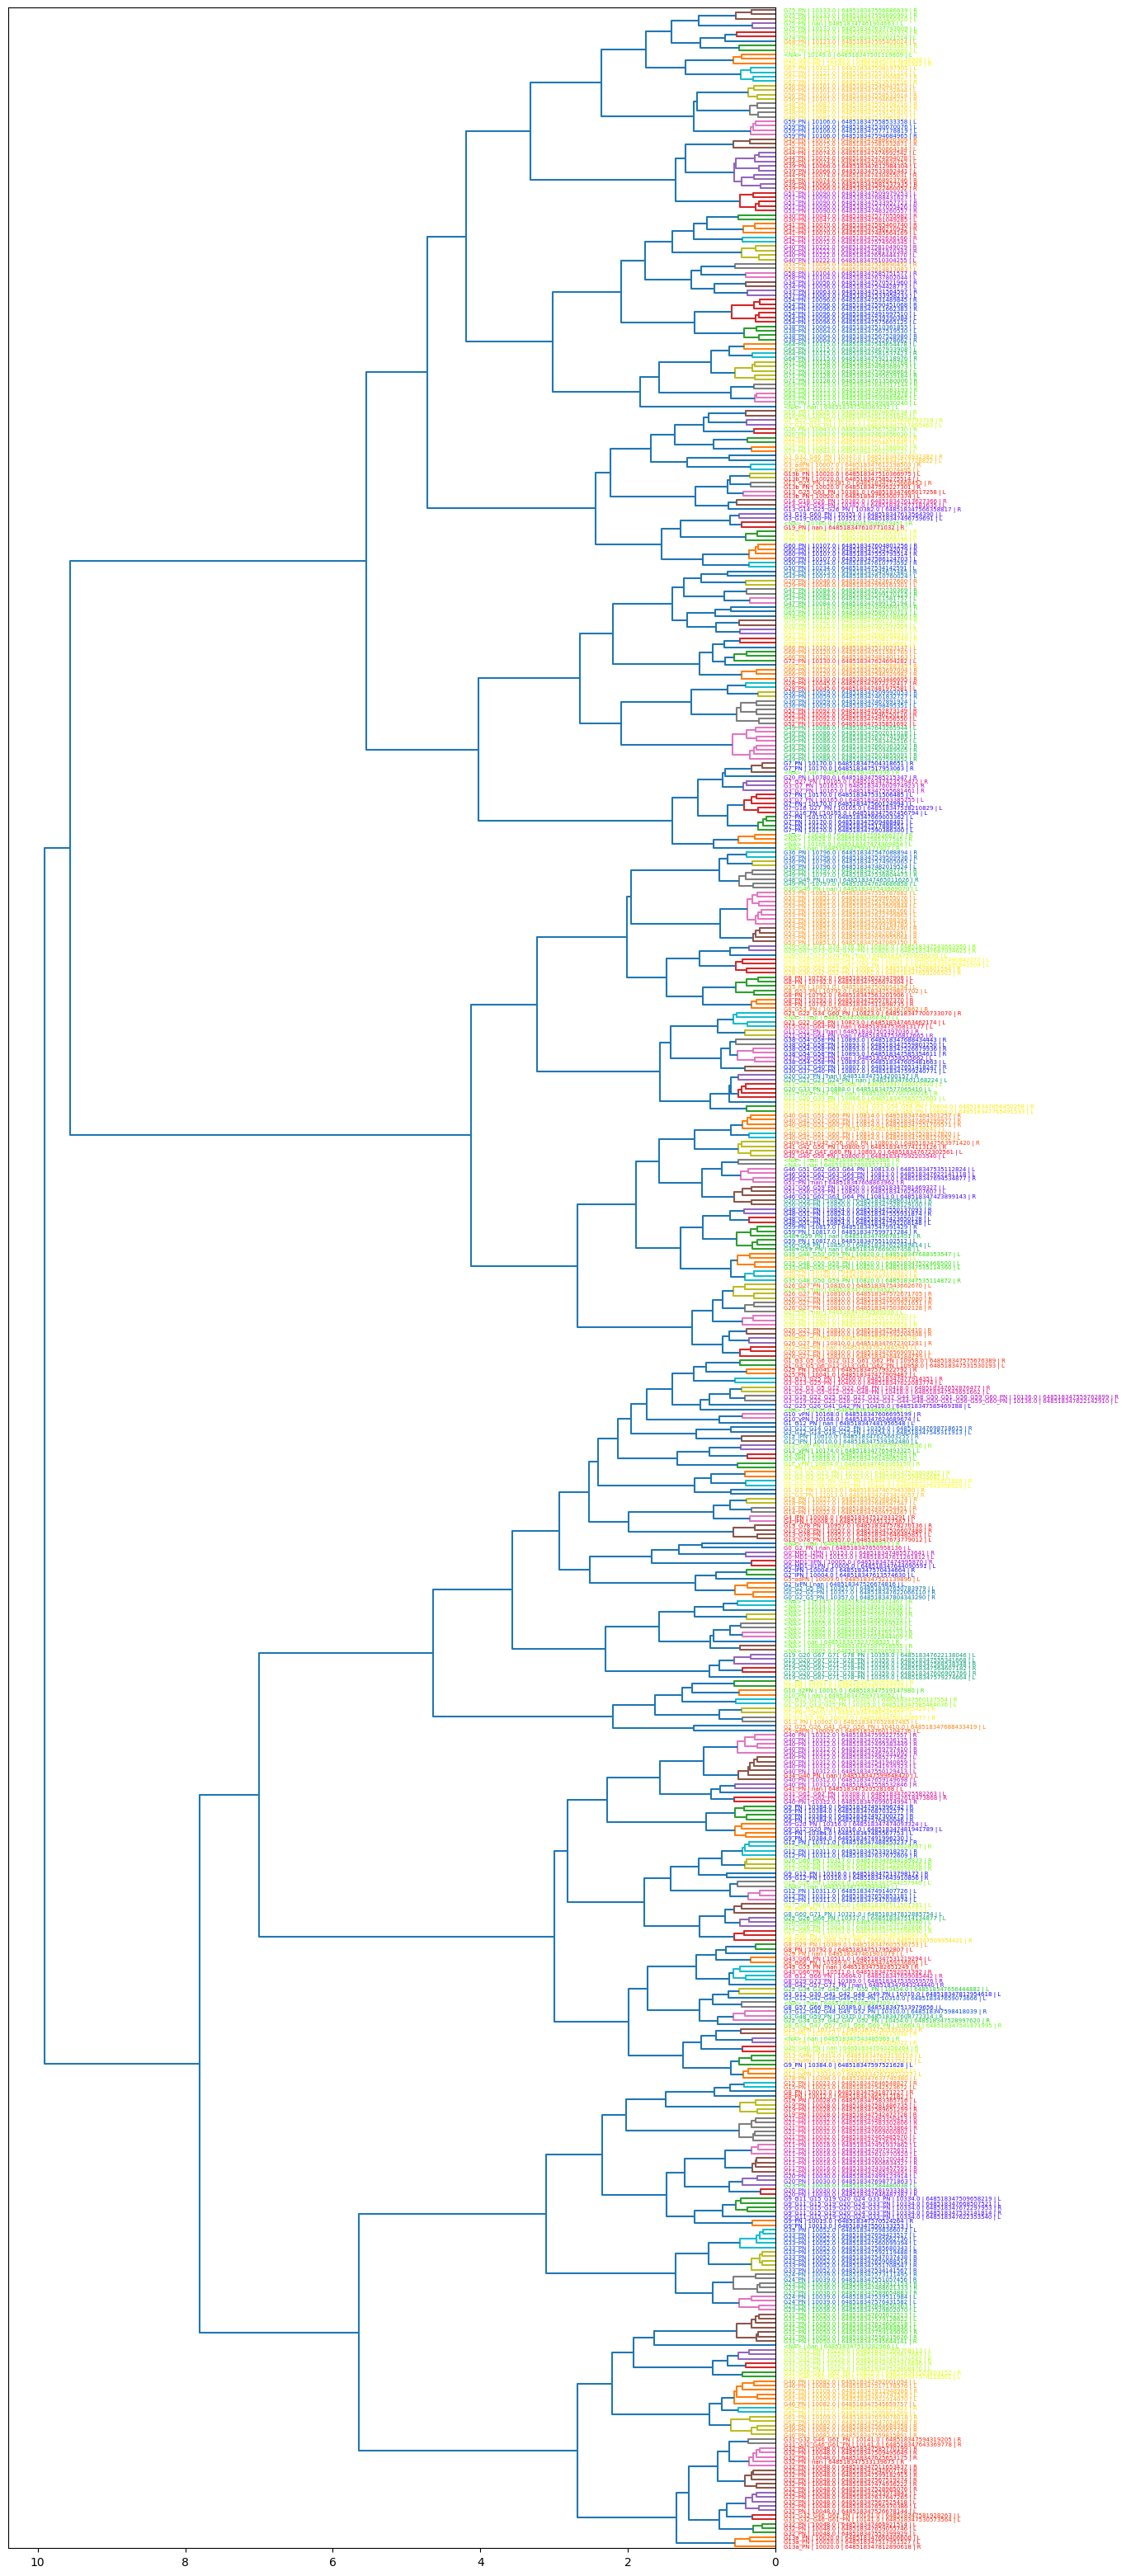

In [120]:
scores.index = scores.index.astype(str) #transform the scores index from int to string

labels = []
for x in scores.index: #get the data for each leaf id from the 4 dataframe colums requested
    row = pns.loc[pns['root_id'] == x].iloc[0]
    label = f"{row['type']} | {row['group']} | {row['root_id']} | {row['side']}"
    labels.append(label)
labels= np.array(labels)

fig, ax = plt.subplots(figsize=(12, 40))
_ = dendrogram(Z, ax=ax, labels=labels, orientation='left', color_threshold = 0.6) #plot dendogram
xlabels = ax.get_ymajorticklabels()
groups = [lbl.get_text().split('|')[0].strip() for lbl in xlabels]
unique_groups = list(dict.fromkeys(groups))
cmap = plt.get_cmap('prism')
n_groups = len(unique_groups)
group_colours = {g:cmap(i/max(n_groups-1, 1)) for i, g in enumerate(unique_groups)}

for lbl in xlabels:
    group = lbl.get_text().split('|')[0].strip()
    lbl.set_color(group_colours[group])
plt.savefig('Dendogram_NBLAST_Aedes.pdf')

In [ ]:
sns.pairplot(score;